# Option Pricing — Démo complète

Ce notebook illustre les trois modèles de pricing d'options implémentés dans ce projet :

1. **Black-Scholes** — formule fermée, options européennes
2. **Binomial Tree (CRR)** — discrétisation, options européennes ET américaines
3. **Monte Carlo** — simulation stochastique, avec réduction de variance
4. **Comparaison** des trois méthodes sur un même jeu de paramètres
5. **Surface de volatilité** — vol implicite extraite de vraies données de marché (yfinance)

> Section 5 nécessite une connexion internet (appel à l'API Yahoo Finance via `yfinance`).
> Si elle échoue (pas de réseau, ticker invalide, rate-limit), un message explicite s'affiche
> sans interrompre le reste du notebook.


## 0. Setup

In [1]:
import sys, os

# Permet d'importer les modules models/ et visualisation/ depuis le dossier notebooks/
sys.path.append(os.path.dirname(os.getcwd()))

import numpy as np
import matplotlib.pyplot as plt

from models import black_scholes
from models import binomial_tree
from models import monte_carlo

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True

# Paramètres de référence utilisés dans tout le notebook
S, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.20
print(f"Paramètres de référence : S={S}, K={K}, T={T}y, r={r:.0%}, sigma={sigma:.0%}")


Paramètres de référence : S=100, K=100, T=1.0y, r=5%, sigma=20%


## 1. Black-Scholes

Prix analytique, Greeks, et vérification de la parité call-put.

In [2]:
call_price = black_scholes.price(S, K, T, r, sigma, 'call')
put_price  = black_scholes.price(S, K, T, r, sigma, 'put')

print(f"Call : {call_price:.4f} $")
print(f"Put  : {put_price:.4f} $")


Call : 10.4506 $
Put  : 5.5735 $


In [3]:
g = black_scholes.greeks(S, K, T, r, sigma, 'call')
print("Greeks (Call) :")
for name, val in g.items():
    print(f"  {name.capitalize():6s} = {val:.6f}")


Greeks (Call) :
  Delta  = 0.636831
  Gamma  = 0.018762
  Vega   = 0.375240
  Theta  = -0.017573
  Rho    = 0.532325


In [4]:
parity = black_scholes.put_call_parity_check(S, K, T, r, sigma)
print(f"C - P            = {parity['lhs']:.6f}")
print(f"S - K*e^(-rT)     = {parity['rhs']:.6f}")
print(f"Erreur            = {parity['error']:.2e}", "OK" if parity['error'] < 1e-10 else "ECHEC")

sigma_impl = black_scholes.implied_vol(call_price, S, K, T, r, 'call')
print(f"\nVol. implicite retrouvée à partir du prix Call : {sigma_impl:.4%} (originale : {sigma:.4%})")


C - P            = 4.877058
S - K*e^(-rT)     = 4.877058
Erreur            = 0.00e+00 OK

Vol. implicite retrouvée à partir du prix Call : 20.0000% (originale : 20.0000%)


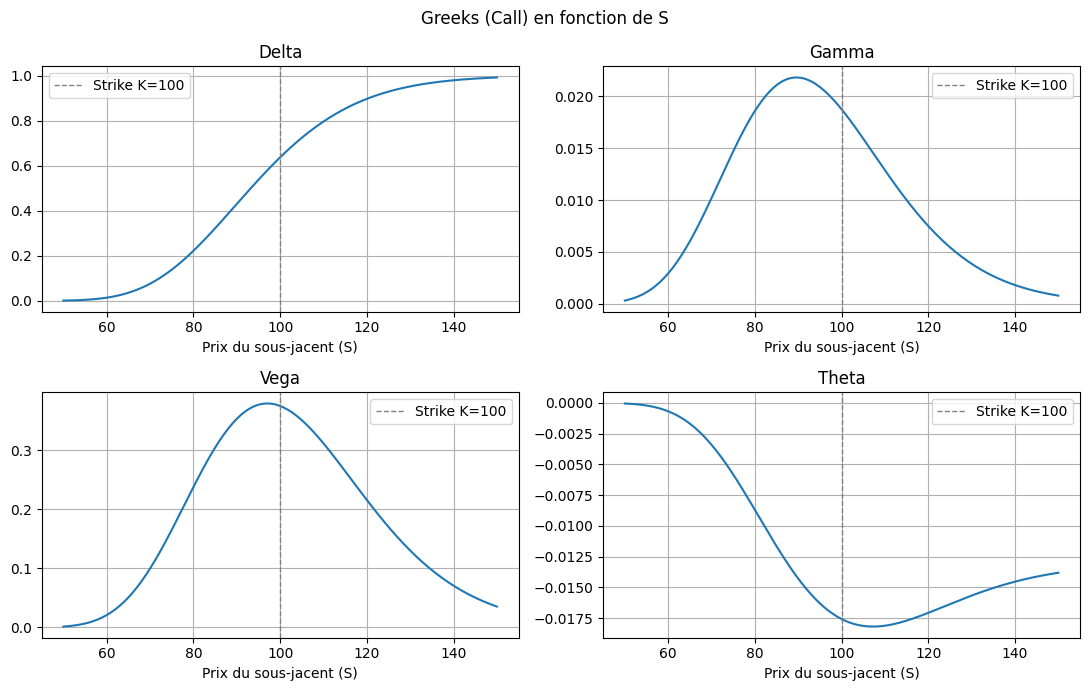

In [5]:
# Greeks en fonction du prix du sous-jacent
S_range = np.linspace(50, 150, 200)
deltas, gammas, vegas, thetas = [], [], [], []

for s in S_range:
    gk = black_scholes.greeks(s, K, T, r, sigma, 'call')
    deltas.append(gk['delta'])
    gammas.append(gk['gamma'])
    vegas.append(gk['vega'])
    thetas.append(gk['theta'])

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (name, vals) in zip(axes.flat, [('Delta', deltas), ('Gamma', gammas), ('Vega', vegas), ('Theta', thetas)]):
    ax.plot(S_range, vals)
    ax.axvline(K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.set_title(name)
    ax.set_xlabel('Prix du sous-jacent (S)')
    ax.legend()
fig.suptitle('Greeks (Call) en fonction de S')
fig.tight_layout()
plt.show()


## 2. Binomial Tree (CRR)

Comparaison européen vs américain, prime d'exercice anticipé, et convergence vers Black-Scholes.

In [6]:
params = binomial_tree.crr_params(T, r, sigma, N=200)
print("Paramètres CRR (N=200) :")
for k, v in params.items():
    print(f"  {k} = {v:.6f}")


Paramètres CRR (N=200) :
  dt = 0.005000
  u = 1.014243
  d = 0.985957
  p = 0.505304


In [7]:
print("Binomial (européen) vs Black-Scholes :")
for otype in ['call', 'put']:
    p_bin = binomial_tree.price(S, K, T, r, sigma, 200, otype, 'european')
    p_bs  = black_scholes.price(S, K, T, r, sigma, otype)
    print(f"  {otype.capitalize():4s} : Binomial = {p_bin:.4f}  |  BS = {p_bs:.4f}  |  Erreur = {abs(p_bin - p_bs):.2e}")


Binomial (européen) vs Black-Scholes :
  Call : Binomial = 10.4406  |  BS = 10.4506  |  Erreur = 9.99e-03
  Put  : Binomial = 5.5635  |  BS = 5.5735  |  Erreur = 9.99e-03


In [8]:
print("Prime d'exercice anticipé :")
for otype in ['call', 'put']:
    res = binomial_tree.early_exercise_premium(S, K, T, r, sigma, option_type=otype)
    print(f"\n  {otype.capitalize()} :")
    print(f"    Européen  = {res['european']:.4f} $")
    print(f"    Américain = {res['american']:.4f} $")
    print(f"    Prime     = {res['premium']:.4f} $")


Prime d'exercice anticipé :

  Call :
    Européen  = 10.4406 $
    Américain = 10.4406 $
    Prime     = 0.0000 $

  Put :
    Européen  = 5.5635 $
    Américain = 6.0864 $
    Prime     = 0.5228 $


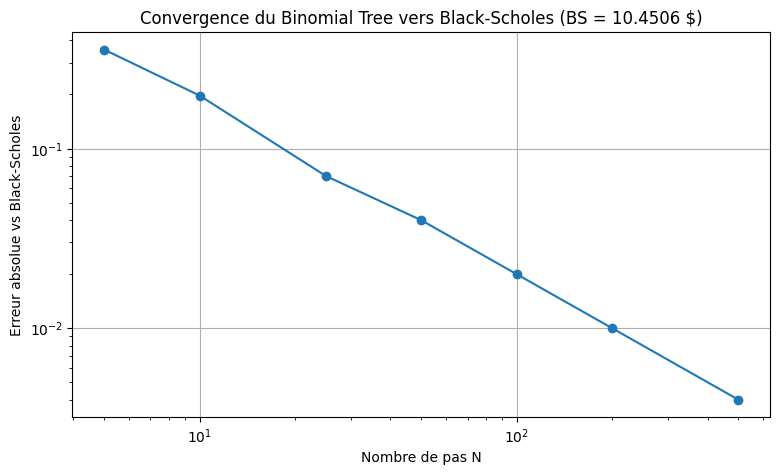

In [9]:
conv = binomial_tree.convergence_vs_bs(S, K, T, r, sigma, 'call')

Ns = [row['N'] for row in conv['convergence']]
errors = [row['error'] for row in conv['convergence']]

plt.plot(Ns, errors, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Nombre de pas N')
plt.ylabel('Erreur absolue vs Black-Scholes')
plt.title(f"Convergence du Binomial Tree vers Black-Scholes (BS = {conv['bs_price']:.4f} $)")
plt.show()


## 3. Monte Carlo

Prix avec intervalle de confiance, réduction de variance par variables antithétiques, et convergence.

In [2]:
for otype in ['call', 'put']:
    res = monte_carlo.price_with_ci(S, K, T, r, sigma, n_sim=100_000, option_type=otype, seed=42)
    bs = black_scholes.price(S, K, T, r, sigma, otype)
    print(f"{otype.capitalize()} :")
    print(f"  Prix MC   = {res['price']:.4f} $  (IC 95% : [{res['ci_lower']:.4f}, {res['ci_upper']:.4f}])")
    print(f"  Prix BS   = {bs:.4f} $")
    print(f"  Erreur    = {abs(res['price'] - bs):.4f} $\n")


Call :
  Prix MC   = 10.4673 $  (IC 95% : [10.3757, 10.5589])
  Prix BS   = 10.4506 $
  Erreur    = 0.0167 $

Put :
  Prix MC   = 5.5797 $  (IC 95% : [5.5259, 5.6335])
  Prix BS   = 5.5735 $
  Erreur    = 0.0062 $



In [3]:
comp = monte_carlo.antithetic_comparison(S, K, T, r, sigma, 'call', n_runs=20)
print(f"BS de référence          : {comp['bs_price']:.4f} $")
print(f"Standard   — écart-type  : {comp['std_volatility']:.5f}")
print(f"Antithétique — écart-type: {comp['anti_volatility']:.5f}")
print(f"Réduction de variance    : {comp['variance_reduction']:.1f}x")


BS de référence          : 10.4506 $
Standard   — écart-type  : 0.16608
Antithétique — écart-type: 0.11726
Réduction de variance    : 2.0x


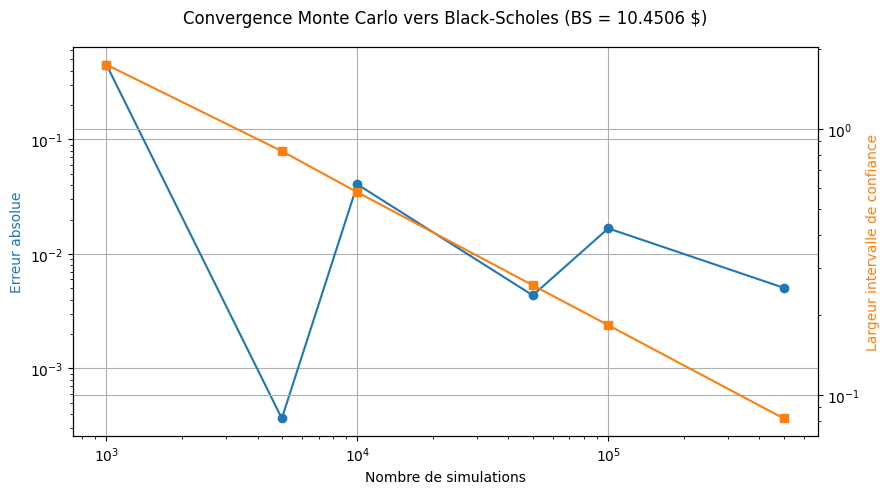

In [4]:
conv_mc = monte_carlo.convergence_vs_bs(S, K, T, r, sigma, 'call')

n_sims = [row['n_sim'] for row in conv_mc['convergence']]
errors_mc = [row['error'] for row in conv_mc['convergence']]
ci_widths = [row['ic_width'] for row in conv_mc['convergence']]

fig, ax1 = plt.subplots()
ax1.plot(n_sims, errors_mc, marker='o', color='tab:blue', label='Erreur vs BS')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Nombre de simulations')
ax1.set_ylabel('Erreur absolue', color='tab:blue')

ax2 = ax1.twinx()
ax2.plot(n_sims, ci_widths, marker='s', color='tab:orange', label='Largeur IC 95%')
ax2.set_yscale('log')
ax2.set_ylabel('Largeur intervalle de confiance', color='tab:orange')

fig.suptitle(f"Convergence Monte Carlo vers Black-Scholes (BS = {conv_mc['bs_price']:.4f} $)")
fig.tight_layout()
plt.show()


## 4. Comparaison des trois méthodes

Même jeu de paramètres, les trois modèles doivent converger vers un prix quasi identique
pour une option européenne (le Binomial et Monte Carlo étant des approximations numériques
de la formule fermée de Black-Scholes).

Méthode                      Prix Call
--------------------------------------
Black-Scholes                  10.4506
Binomial (N=200)               10.4406
Monte Carlo (100k sims)        10.4673


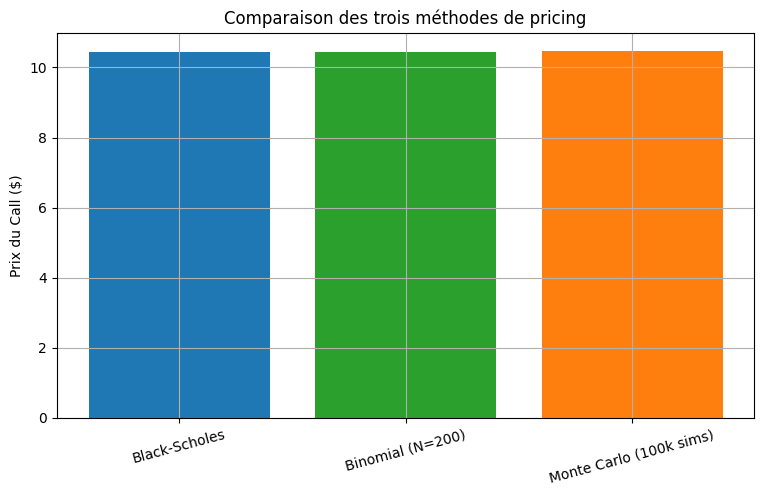

In [13]:
results = {
    'Black-Scholes':  black_scholes.price(S, K, T, r, sigma, 'call'),
    'Binomial (N=200)': binomial_tree.price(S, K, T, r, sigma, 200, 'call', 'european'),
    'Monte Carlo (100k sims)': monte_carlo.price(S, K, T, r, sigma, 100_000, 'call', seed=42),
}

print(f"{'Méthode':<26}{'Prix Call':>12}")
print("-" * 38)
for name, val in results.items():
    print(f"{name:<26}{val:>12.4f}")

plt.bar(results.keys(), results.values(), color=['tab:blue', 'tab:green', 'tab:orange'])
plt.ylabel('Prix du Call ($)')
plt.title('Comparaison des trois méthodes de pricing')
plt.xticks(rotation=15)
plt.show()


## 5. Surface de volatilité (données de marché réelles)

Nécessite une connexion internet. Récupère la chaîne d'options d'un ticker liquide (SPY par
défaut) via `yfinance`, recalcule la vol implicite avec notre propre `black_scholes.implied_vol`,
puis trace le smile et la surface de volatilité 3D.

In [14]:
try:
    from visualisation import vol_surface

    TICKER = 'SPY'
    result = vol_surface.build_and_plot(TICKER, option_type='call', save_html=False)

    df = result['data']
    print(f"\n{len(df)} contrats exploitables pour {TICKER}")
    display(df[['expiration', 'strike', 'T', 'mid_price', 'iv']].head(10))

    result['smile_fig'].show()
    result['surface_fig'].show()

except Exception as e:
    print(
        "Impossible de récupérer les données de marché "
        f"(pas de connexion internet, ticker invalide, ou rate-limit Yahoo Finance) : {e}\n"
        "-> Relancer cette cellule avec une connexion internet active pour voir le smile et la surface."
    )


Récupération de la chaîne d'options pour SPY...


Failed to get ticker 'SPY' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


HTTP Error 403: Host not in allowlist: query1.finance.yahoo.com. Add this host to your network egress settings to allow access.


Impossible de récupérer les données de marché (pas de connexion internet, ticker invalide, ou rate-limit Yahoo Finance) : Expecting value: line 1 column 1 (char 0)
-> Relancer cette cellule avec une connexion internet active pour voir le smile et la surface.
